# RadKlim - Precipitation Climatology over Germany

This notebook describes how to access and use the zarr-version of the [RadKlim](https://opendata.dwd.de/climate_environment/CDC/help/landing_pages/doi_landingpage_RADKLIM_RW_V2017.002-en.html) dataset. The dataset includes hourly accumulated rainfall and five-minute rain-rate data over Germany, which is derived from the German Weather Service (DWD) radar network. The RadKlim dataset has been extended annually since the first version released in 2017 (covering 2001-2017). The the `v0.1.0` zarr version of the dataset includes up to Extension 6, **covering 2001-2023**.

The dataset was created by processing the netCDF files for the hourly and five-minute precipitation data into two separate zarr datasets which are described below. The processing was done with code hosted on https://github.com/mlcast-community/mlcast-dataset-radklim.

In [2]:
from intake import open_catalog
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [5]:
# open the mlcast datasets intake catalog
cat = open_catalog(
    "https://raw.githubusercontent.com/mlcast-community/mlcast-datasets/main/catalog.yml"
)
list(cat.precipitation)

['radklim_hourly']

# Hourly rainfall amount

One part of RadKlim is the hourly rainfall amount which is available in the intake catalog as `radklim_hourly`.

In [5]:
ds = cat.precipitation.radklim_hourly.to_dask()
ds

<xarray.Dataset> Size: 798GB
Dimensions:  (time: 201600, y: 1100, x: 900)
Coordinates:
    lat      (y, x) float64 8MB dask.array<chunksize=(1100, 900), meta=np.ndarray>
    lon      (y, x) float64 8MB dask.array<chunksize=(1100, 900), meta=np.ndarray>
  * time     (time) datetime64[ns] 2MB 2001-01-01T00:50:00 ... 2023-12-31T23:...
  * x        (x) float64 7kB -443.0 -442.0 -441.0 -440.0 ... 454.0 455.0 456.0
  * y        (y) float64 9kB -4.758e+03 -4.757e+03 ... -3.66e+03 -3.659e+03
Data variables:
    RR       (time, y, x) float32 798GB dask.array<chunksize=(1, 1100, 900), meta=np.ndarray>
    crs      float64 8B ...
Attributes:
    Author:                Harald Rybka, Katharina Lengfeld
    Conventions:           CF-1.6
    history:               Created at 2021-07-09 08:48:10.797384
    institution:           Deutscher Wetterdienst (DWD)
    reference:             10.5676/DWD/RADKLIM_RW_V2017.002
    title:                 RADKLIM - radar-based precipitation climatology
    zarr_creation:         created with mlcast_dataset_radklim (https://githu...
    zarr_dataset_version:  0.1.0

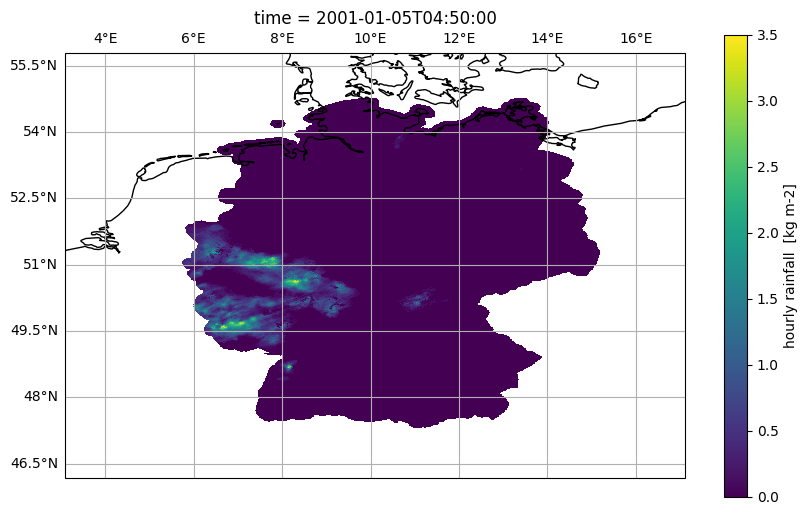

In [7]:
var_name = "RR"

crs_name = ds[var_name].grid_mapping
data_crs = ccrs.Projection(ds[crs_name].crs_wkt)

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(10, 6),
)
ax.coastlines()
ax.gridlines(draw_labels=["top", "left"])
ds[var_name].isel(time=100).plot(
    ax=ax, transform=data_crs, cmap="viridis", add_colorbar=True
)